# 05 · Model validation — 4stacks_5x5_norm (global normalisation)

Same as `05_validate_4stacks_5x5_norm.ipynb` but BFP is normalised globally
(p1/p99 on the full raw image before splitting) to match how the model was trained,
and `normalize=False` is passed to `model.eval()`.

**Model:** `models/finetuned/4stacks_5x5_norm`

**Validation data:** Scene-02 v1 annotations (3×3 ground truth masks), images
loaded from the full raw stack with global BFP normalisation.

**Outputs** (under `figures/validation/<stem>/global_norm/`):
- `val_comparison.png`, `ap_bars.png`, `cell_counts.png`

**Environment:** `cellpose`

Global-normalisation version of the 4stacks_5x5_norm validation

Run on Scene-05-20260416-C3M2_Pcol_2-A01Export-07_c1-4_stack, the same internal validation stack as done to generate og figures

Images loaded from raw stack with global BFP p1/p99 normalisation to match training conditions.

In [ ]:
import json
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from aquarel import load_theme
from cellpose import models, metrics, utils

import sys
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')
sys.path.insert(0, str(PROJECT_ROOT))
from src.io import load_stack, split_image, stitch_masks
from src.preprocess import normalize_for_segmentation

In [ ]:
VAL_IMAGE   = 'Scene-05-20260416-C3M2_Pcol_2-A01Export-07_c1-4_stack'

N_ROWS      = 5
N_COLS      = 5
N_SHOW      = 10
MIN_CELLS   = 3
DIAMETER_PX = round(1.5 / 0.035)  # 43 px
AQUAREL_THEME = 'boxy_light'

RAW_DIR     = PROJECT_ROOT / 'data' / 'raw' / '16bit'
PATCHES_DIR = PROJECT_ROOT / 'data' / 'patches' / 'v2'   
RUNS_DIR    = PROJECT_ROOT / 'models' / 'finetuned'
FIG_DIR     = PROJECT_ROOT / 'figures' / 'validation' / Path(VAL_IMAGE).stem / 'global_norm'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

## Discover fine-tuned models

In [3]:
# Auto-discover all runs in models/finetuned/ that contain a model file
run_models = {}   # run_name → model path
for run_dir in sorted(RUNS_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    model_files = list((run_dir / 'models').glob('*')) if (run_dir / 'models').exists() else []
    if not model_files:
        continue
    run_models[run_dir.name] = model_files[0]   # one model per run
    info_path = run_dir / 'run_info.json'
    if info_path.exists():
        info = json.loads(info_path.read_text())
        print(f'  {run_dir.name:<15}  {model_files[0].name:<25}  '
              f'AP base={info.get("ap_base","?"):.3f}  '
              f'AP ft={info.get("ap_finetuned","?"):.3f}  '
              f'({info.get("n_train_patches","?")} train patches)')
    else:
        print(f'  {run_dir.name:<15}  {model_files[0].name}')

print(f'\n{len(run_models)} fine-tuned model(s) found + base cpsam')

  1stack           cpsam_finetuned
  4stacks_5x5_norm  cpsam_4stacks_5x5_norm     AP base=0.641  AP ft=0.724  (75 train patches)
  5stacks          cpsam_5stacks              AP base=0.884  AP ft=0.842  (35 train patches)

3 fine-tuned model(s) found + base cpsam


## Load ground truth patches (global normalisation)

Loads the full raw stack, normalises BFP globally (p1/p99), then extracts
the same patch regions as the v1 3×3 grid. Ground truth masks come from
the v1 `_seg.npy` files.

In [ ]:
stem      = Path(VAL_IMAGE).stem
patch_dir = PATCHES_DIR / stem
assert patch_dir.exists(), f'{patch_dir} not found'

# Global BFP normalisation from full raw stack
print(f'Loading {VAL_IMAGE}...')
stack    = load_stack(RAW_DIR / VAL_IMAGE)
bfp_norm = normalize_for_segmentation(stack[0].astype(np.float32))
patches  = split_image(bfp_norm, N_ROWS, N_COLS)
print(f'Stack {stack.shape}  →  {N_ROWS}×{N_COLS} patches, BFP normalised globally')

val_imgs, val_masks, val_names = [], [], []
for p in patches:
    r, c     = p['row'], p['col']
    seg_path = patch_dir / f'patch_r{r}_c{c}_seg.npy'
    if not seg_path.exists():
        print(f'  Skip patch_r{r}_c{c} — no _seg.npy')
        continue
    mask = np.load(str(seg_path), allow_pickle=True).item()['masks'].astype(np.int32)
    if mask.max() < MIN_CELLS:
        print(f'  Skip patch_r{r}_c{c} — only {mask.max()} cells < {MIN_CELLS}')
        continue
    y0, x0, h, w = p['y0'], p['x0'], p['h'], p['w']
    val_imgs.append(bfp_norm[y0:y0+h, x0:x0+w])
    val_masks.append(mask)
    val_names.append(f'patch_r{r}_c{c}')

assert len(val_imgs) >= 1, 'No annotated patches found'
print(f'\nLoaded {len(val_imgs)} annotated patches')
for name, mask in zip(val_names, val_masks):
    print(f'  {name}: {mask.max()} cells')

## Run inference — all models

In [ ]:
eval_kw = dict(diameter=DIAMETER_PX, channels=[0, 0],
               normalize=False,   # images are already globally normalised
               flow_threshold=0.4, cellprob_threshold=0.0)

predictions = {}
PREFERRED_MODEL_ORDER = ['base cpsam', '1stack', '5stack', '4stacks_5x5_norm']

print('Running base cpsam...')
model_base = models.CellposeModel(gpu=True)
predictions['base cpsam'] = [model_base.eval(img, **eval_kw)[0] for img in val_imgs]
print(f'  done')

for run_name, model_path in run_models.items():
    print(f'Running {run_name}...')
    m = models.CellposeModel(gpu=True, pretrained_model=str(model_path))
    predictions[run_name] = [m.eval(img, **eval_kw)[0] for img in val_imgs]
    print(f'  done')

ordered_model_labels = [label for label in PREFERRED_MODEL_ORDER if label in predictions]
ordered_model_labels += [label for label in predictions if label not in ordered_model_labels]
predictions = {label: predictions[label] for label in ordered_model_labels}

print(f'\nModels evaluated: {ordered_model_labels}')

## AP @ IoU 0.5

In [6]:
ap_per_model = {}  # model_label → array of per-patch AP values
print(f'{"Model":<20}  {"Mean AP@0.5":>12}  Per-patch')
print('-' * 60)
for label, preds in predictions.items():
    ap = metrics.average_precision(val_masks, preds)[0][:, 0]
    ap_per_model[label] = ap
    per_patch = '  '.join(f'{v:.3f}' for v in ap)
    print(f'{label:<20}  {ap.mean():>12.3f}  {per_patch}')

Model                  Mean AP@0.5  Per-patch
------------------------------------------------------------
base cpsam                   0.685  0.676  0.855  0.565  0.788  0.765  0.571  0.642  0.619
1stack                       0.625  0.675  0.801  0.586  0.707  0.558  0.536  0.568  0.571
4stacks_5x5_norm             0.702  0.611  0.803  0.609  0.806  0.667  0.722  0.702  0.694
5stacks                      0.678  0.694  0.784  0.615  0.775  0.641  0.538  0.742  0.638


## Figure: val comparison

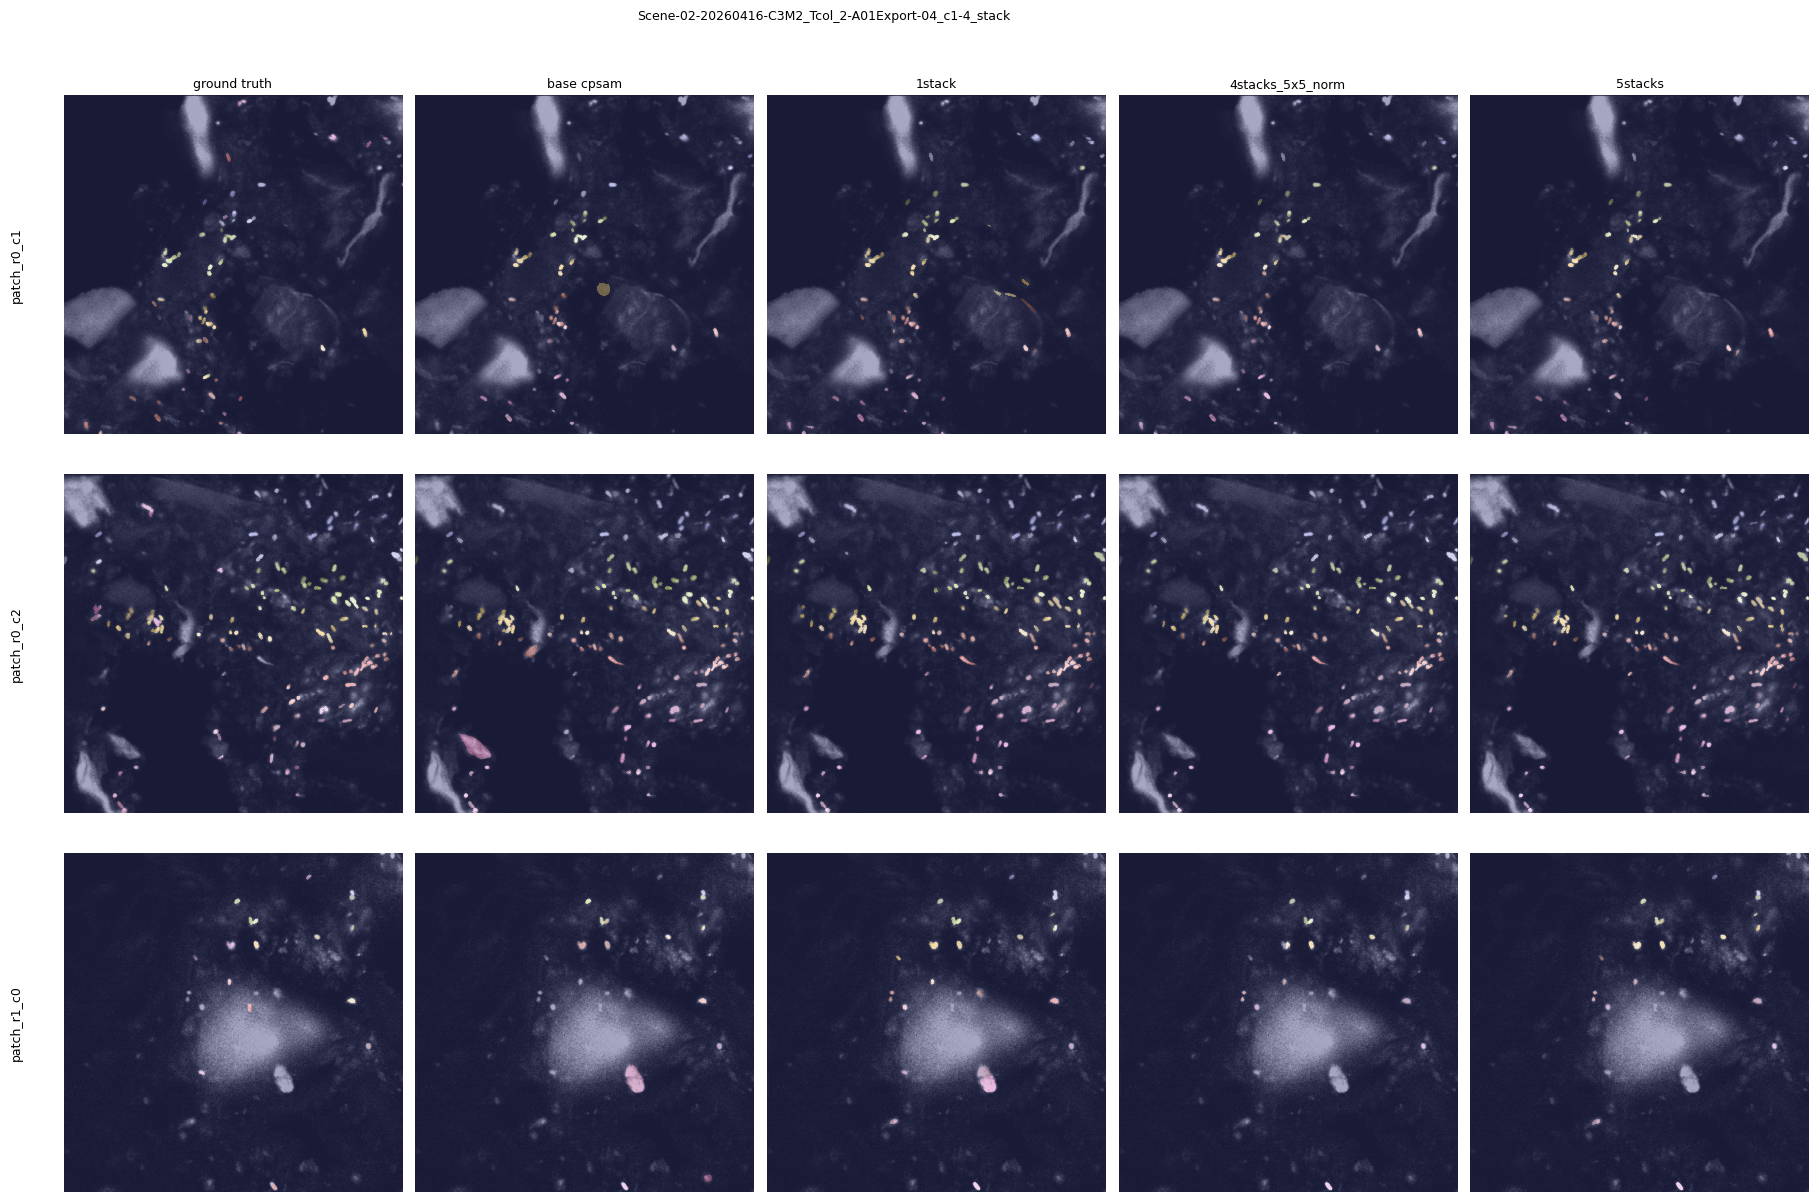

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/val_comparison.png


In [ ]:
def norm(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)

def show_mask(ax, img_norm, mask):
    ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    if mask.max() > 0:
        ax.imshow(mask, cmap='tab20b', alpha=0.45, interpolation='nearest')

model_labels = list(predictions.keys())
n_show = min(N_SHOW, len(val_imgs))
n_cols = 1 + len(model_labels)   # ground truth + one per model

fig, axes = plt.subplots(n_show, n_cols, figsize=(4 * n_cols, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    img_n = norm(val_imgs[i])
    show_mask(axes[i, 0], img_n, val_masks[i])
    axes[i, 0].text(-0.12, 0.5, val_names[i],
                    transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='right', fontsize=9, clip_on=False)
    for j, label in enumerate(model_labels):
        show_mask(axes[i, j + 1], img_n, predictions[label][i])

axes[0, 0].set_title('ground truth', fontsize=9)
for j, label in enumerate(model_labels):
    axes[0, j + 1].set_title(label, fontsize=9)
for ax in axes.flat:
    ax.axis('off')

fig.suptitle(stem, fontsize=9, y=1.01)
fig.tight_layout()
fig.subplots_adjust(left=0.12)
fig.savefig(FIG_DIR / 'val_comparison.svg', dpi=100, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/val_comparison.svg')

## Figure: AP bars

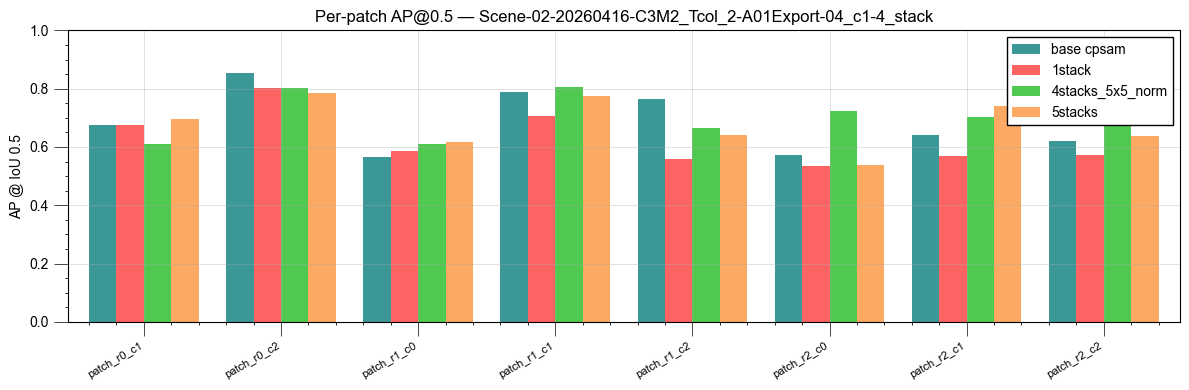

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/ap_bars.png


In [ ]:
n_models = len(ap_per_model)
x = np.arange(len(val_names))
w = 0.8 / n_models
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * w

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(val_names) * 1.5), 4))
for (label, ap), offset in zip(ap_per_model.items(), offsets):
    ax.bar(x + offset, ap, w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(val_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('AP @ IoU 0.5')
ax.set_ylim(0, 1)
ax.set_title(f'Per-patch AP@0.5 — {stem}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'ap_bars.svg', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/ap_bars.svg')

## Figure: cell counts

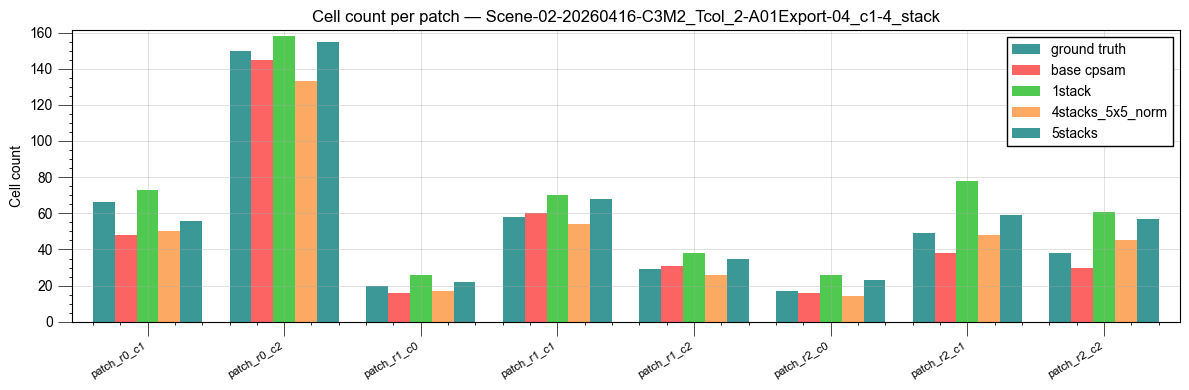

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/cell_counts.png


In [ ]:
all_labels  = ['ground truth'] + list(predictions.keys())
all_counts  = [[int(m.max()) for m in val_masks]] + \
              [[int(m.max()) for m in preds] for preds in predictions.values()]
n_bars = len(all_labels)
x  = np.arange(len(val_names))
w  = 0.8 / n_bars
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * w

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(val_names) * 1.5), 4))
for label, counts, offset in zip(all_labels, all_counts, offsets):
    ax.bar(x + offset, counts, w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(val_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Cell count')
ax.set_title(f'Cell count per patch — {stem}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'cell_counts.svg', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/cell_counts.svg')

In [ ]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(8, 5))

for label, preds in predictions.items():
    ap_out = metrics.average_precision(val_masks, preds, threshold=iou_thresholds)
    tp = ap_out[1]   # (n_patches, n_thresholds)
    fp = ap_out[2]
    fn = ap_out[3]

    precision = tp.sum(axis=0) / np.maximum(tp.sum(axis=0) + fp.sum(axis=0), 1e-6)
    recall    = tp.sum(axis=0) / np.maximum(tp.sum(axis=0) + fn.sum(axis=0), 1e-6)
    f1        = 2 * precision * recall / np.maximum(precision + recall, 1e-6)

    ax.plot(iou_thresholds, f1, marker='o', markersize=4, label=label)

ax.set_xlabel('IoU threshold')
ax.set_ylabel('F1 score')
ax.set_title(f'F1 vs IoU threshold — {stem}')
ax.set_xlim(0.48, 1.0)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'f1_curve.svg', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/f1_curve.svg')